#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 9: XGBoost Time Series Forecasting
---
Topics

*  1. Extracting Time Based Features
*  2. Feature Engineering
*  3. Time Based Train-Test Split
*  4. XGBoost Model Training
*  5. Model Evaulation

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Forecasting_Cleaned.csv to Forecasting_Cleaned.csv


## 1. Extracting Time Based Features

In [ ]:
# Load dataset
df = pd.read_csv("Forecasting_Cleaned.csv")

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract time-based features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['dayofyear'] = df['Date'].dt.dayofyear
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)

# Drop the original 'Date' column as it's no longer needed in its original form
df = df.drop(columns=['Date'])

# Display basic info
df.head()

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return,year,month,day,dayofweek,dayofyear,weekofyear
0,14.921,15.738,14.619,15.629,234334000,NaN,0.708,1.118,NaN,2015,1,1,3,1,1
1,14.663,15.157,14.325,15.016,375546000,-0.017,0.352,0.832,0.017,2015,1,8,3,8,2
2,14.863,15.300,14.262,14.700,420752000,0.014,-0.163,1.038,0.014,2015,1,15,3,15,3
3,15.196,15.847,15.000,15.000,380256000,0.022,-0.196,0.847,0.022,2015,1,22,3,22,4
4,18.237,18.391,14.967,15.236,1062542000,0.200,-3.001,3.425,0.200,2015,1,29,3,29,5


Convert the 'Date' column to datetime objects and extract useful numerical features like year, month, day, day of week, and week of year.

After extraction, the original 'Date' column will be removed from the DataFrame, and the model training and prediction steps will be updated to reflect this change.

## 2. Feature Engineering (LAG FEATURES)

In [ ]:
# Assume the target column is named 'Close' (change if needed)
target_col = 'Close'

# Create lag features
def create_lags(data, col, lags=5):
    df = data.copy()
    for i in range(1, lags+1):
        df[f'lag_{i}'] = df[col].shift(i)
    return df

df = create_lags(df, target_col, lags=10)

# Drop NA values from lagging
df = df.dropna()

df.head()

,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return,year,...,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
10,18.757,18.799,18.334,18.441,249338000,0.024,-0.316,0.465,0.024,2015,...,18.319,19.136,19.268,18.669,18.757,18.237,15.196,14.863,14.663,14.921
11,18.548,19.088,18.514,18.694,271526000,-0.011,0.146,0.574,0.011,2015,...,18.757,18.319,19.136,19.268,18.669,18.757,18.237,15.196,14.863,14.663
12,18.513,18.885,18.282,18.479,246498000,-0.002,-0.034,0.603,0.002,2015,...,18.548,18.757,18.319,19.136,19.268,18.669,18.757,18.237,15.196,14.863
13,19.060,19.079,18.450,18.525,190346000,0.030,-0.535,0.629,0.030,2015,...,18.513,18.548,18.757,18.319,19.136,19.268,18.669,18.757,18.237,15.196
14,19.173,19.390,18.940,19.033,227542000,0.006,-0.139,0.450,0.006,2015,...,19.060,18.513,18.548,18.757,18.319,19.136,19.268,18.669,18.757,18.237


In time series forecasting, XGBoost cannot directly understand sequential data. So we convert the problem into supervised learning using lagged values of the target variable.

## 3. Time Based Train-Test Split

In [ ]:
# Train-test split (time-based)
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(columns=[target_col])
y_train = train[target_col]

X_test = test.drop(columns=[target_col])
y_test = test[target_col]

We do NOT shuffle data because time series requires chronological order. This avoids data leakage and simulates real-world forecasting conditions.

## 4. XGBoost Model Training


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(),
    params,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error')

XGBoost is an ensemble of decision trees trained using gradient boosting. It captures nonlinear relationships and interactions between lag features.

Key advantage: handles nonlinear patterns better than ARIMA.

## 5. Model Evaulation

In [ ]:
results = pd.DataFrame(search.cv_results_)
results.sort_values("rank_test_score")[[
    "params",
    "mean_test_score",
    "rank_test_score"
]]

best_model = search.best_estimator_
search.best_params_

{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

In [ ]:
# Predictions
preds = best_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f'RMSE: {rmse:.4f}')

RMSE: 30.9697


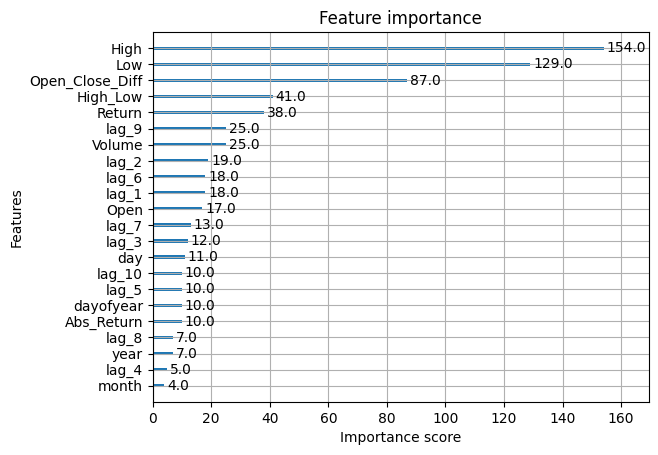

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(best_model)
plt.show()

Importance is a measure from XGBoost that shows which input features your model relied on the most when making predictions.

Y-axis → feature names

X-axis → importance score

Bars → how much each feature contributed to the model

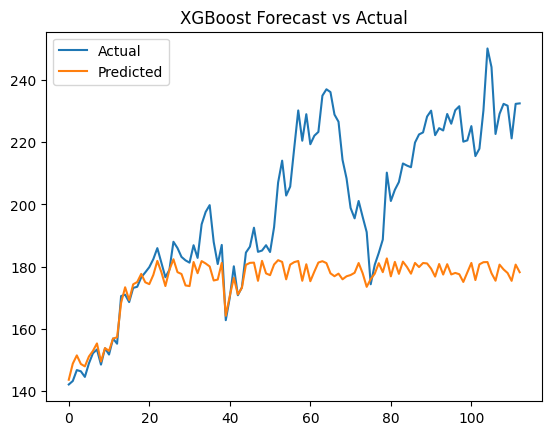

In [ ]:
# Plot results
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('XGBoost Forecast vs Actual')
plt.show()